<a href="https://colab.research.google.com/github/DinaKSari/244107020072_PEMBELAJARAN_MESIN/blob/main/TG2_244107020072_DINA_KUMALA_SARI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# praktikum 1

In [1]:
!pip install -q pandas matplotlib numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
df.head()

# jika mau lebih banyak data
# df.head(100)

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [7]:
#langkah 2
#cek tipe dimensi
df.shape

# cek tipe data
df.info()

#jumlah data hilang
df.isnull().sum()

#ringkasan nilai statik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB


,Plant_ID,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
count,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000
mean,35.441780,28.142222,64.873462,598.045440,6.399211,23.141054,82.655999,0.648735
std,20.243433,4.670521,8.988985,115.713047,0.234418,13.077107,8.406938,0.089890
min,1.000000,18.000000,50.000000,400.000000,6.000000,1.000000,64.400000,0.500000
25%,18.000000,23.600000,57.000000,498.000000,6.200000,12.000000,74.480000,0.570000
50%,35.000000,30.200000,65.000000,593.000000,6.400000,23.000000,86.360000,0.650000
75%,53.000000,31.500000,73.000000,699.000000,6.600000,34.000000,88.700000,0.730000
max,70.000000,33.500000,80.000000,800.000000,6.800000,48.000000,92.300000,0.800000


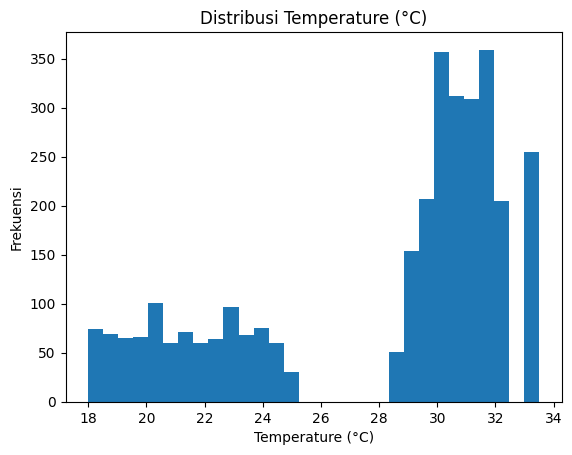

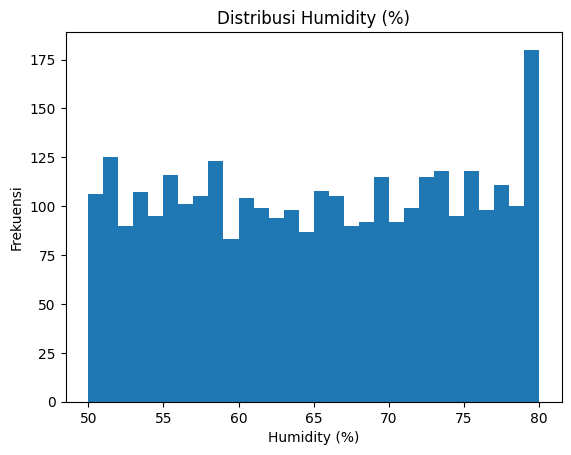

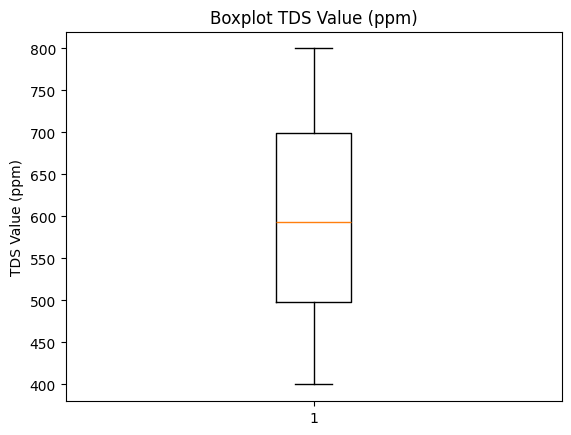

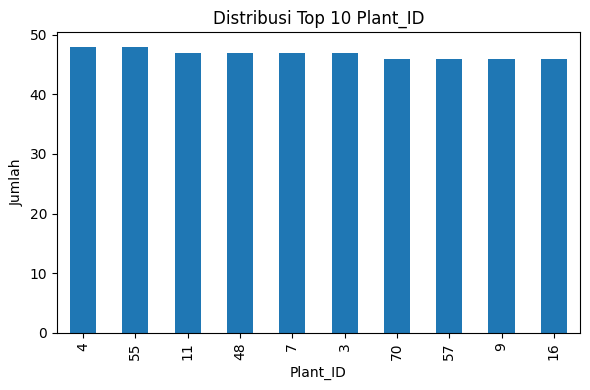

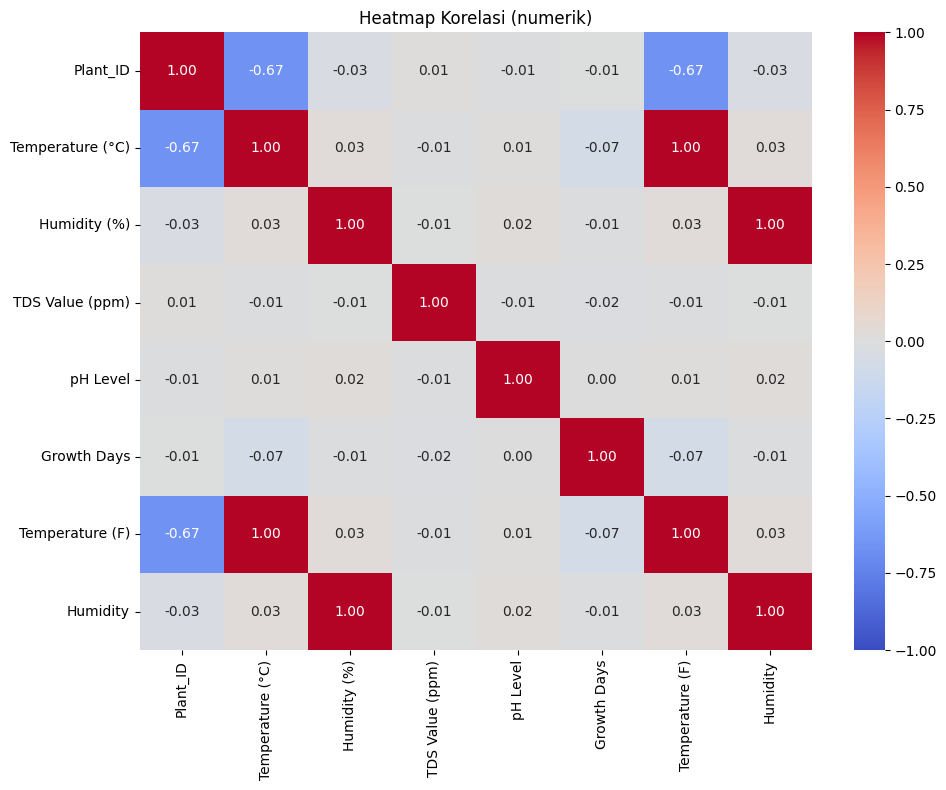

Korelasi terhadap Growth Days:
Growth Days         1.000000
pH Level            0.003043
Plant_ID           -0.005159
Humidity (%)       -0.014531
Humidity           -0.014531
TDS Value (ppm)    -0.020667
Temperature (F)    -0.074549
Temperature (°C)   -0.074549
Name: Growth Days, dtype: float64


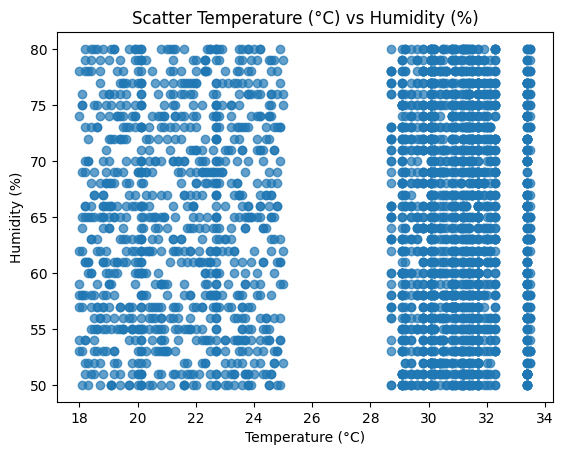

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# langkah 3
# inspeksi distribusi data
num_cols = ['Temperature (°C)', 'Humidity (%)']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col); plt.ylabel('Frekuensi')
    plt.show()

# inspeksi outlier (Menguji outlier pada TDS Value)
plt.figure()
plt.boxplot(df['TDS Value (ppm)'].dropna(), vert=True)
plt.title('Boxplot TDS Value (ppm)')
plt.ylabel('TDS Value (ppm)')
plt.show()

# inspeksi konsumsi variabel komputative

cat_cols = ['Plant_ID'] # Hanya memiliki ID atau Date
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
df['Plant_ID'].value_counts(dropna=False).head(10).plot(kind='bar', ax=axes)
axes.set_title('Distribusi Top 10 Plant_ID')
axes.set_xlabel('Plant_ID')
axes.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

# inspeksi korelasi
# heatmap
num_only = df.select_dtypes(include=[np.number])
corr = num_only.corr(numeric_only=True)

plt.figure(figsize=(10, 8)) # Diperbesar agar teks korelasi lebih mudah dibaca
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title('Heatmap Korelasi (numerik)')
plt.tight_layout()
plt.show()

# mendapatkan informasi nilai korelasi variabel lain terhadap Growth Days
print("Korelasi terhadap Growth Days:")
print(corr['Growth Days'].sort_values(ascending=False))

# scatter plot
plt.figure()
plt.scatter(df['Temperature (°C)'], df['Humidity (%)'], alpha=0.7)
plt.xlabel('Temperature (°C)'); plt.ylabel('Humidity (%)')
plt.title('Scatter Temperature (°C) vs Humidity (%)')
plt.show()

# praktikum 2

In [9]:
# data amputation
#langkah 0 persiapan
import pandas as pd
import numpy as np

In [10]:
#memuat data
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')

# Tampilkan 5 data teratas
df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [11]:
#langkah 2
#cek tipe dimensi
df.shape

# cek tipe data
df.info()

#jumlah data hilang
df.isnull().sum()

#ringkasan nilai statik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB


,Plant_ID,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
count,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000
mean,35.441780,28.142222,64.873462,598.045440,6.399211,23.141054,82.655999,0.648735
std,20.243433,4.670521,8.988985,115.713047,0.234418,13.077107,8.406938,0.089890
min,1.000000,18.000000,50.000000,400.000000,6.000000,1.000000,64.400000,0.500000
25%,18.000000,23.600000,57.000000,498.000000,6.200000,12.000000,74.480000,0.570000
50%,35.000000,30.200000,65.000000,593.000000,6.400000,23.000000,86.360000,0.650000
75%,53.000000,31.500000,73.000000,699.000000,6.600000,34.000000,88.700000,0.730000
max,70.000000,33.500000,80.000000,800.000000,6.800000,48.000000,92.300000,0.800000


In [12]:
# langkah 3, data imputation (penanganan nilai kosong/hilang)

# 1. Imputasi dengan Mean (Rata-rata)
df['Temperature (°C)'] = df['Temperature (°C)'].fillna(df['Temperature (°C)'].mean())

# 2. Imputasi dengan Nilai Konstan
df['pH Level'] = df['pH Level'].fillna(6.5)

# 3. Imputasi dengan Modus (Nilai paling sering muncul)
df['Humidity (%)'] = df['Humidity (%)'].fillna(df['Humidity (%)'].mode()[0])

In [13]:
#validasi hasil
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB


praktikum 3

In [17]:
#load data
dpath = 'lettuce_dataset_updated.csv'
df = pd.read_csv(dpath, encoding='latin1')
df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [18]:
#slice data
df = df[['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']]
df.head()

,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,33.4,53,582,6.4,1
1,33.5,53,451,6.1,2
2,33.4,59,678,6.4,3
3,33.4,68,420,6.4,4
4,33.4,74,637,6.5,5


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Temperature (°C)'] = le.fit_transform(df['Temperature (°C)'])
df['TDS Value (ppm)'] = le.fit_transform(df['TDS Value (ppm)'])

In [21]:
#verifikasi
df.head()

,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,96,53,182,6.4,1
1,97,53,51,6.1,2
2,96,59,278,6.4,3
3,96,68,20,6.4,4
4,96,74,237,6.5,5


In [22]:
from sklearn.preprocessing import StandardScaler

# standarisasi
std = StandardScaler()
df['Temperature (°C)'] = std.fit_transform(df[['Temperature (°C)']])

# verifikasi lagi
df.head()

,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,0.999127,53,182,6.4,1
1,1.036940,53,51,6.1,2
2,0.999127,59,278,6.4,3
3,0.999127,68,20,6.4,4
4,0.999127,74,237,6.5,5


# praktikum 4

In [23]:
#persiapan
!pip install -q opencv-python matplotlib

In [24]:
import cv2
import matplotlib.pyplot as plt

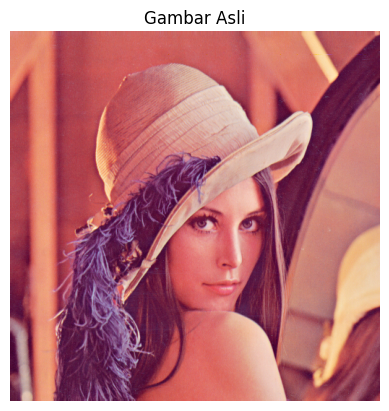

In [26]:
# Membaca gambar (BGR default di OpenCV)
img = cv2.imread("Lenna.png")

# Konversi BGR → RGB (agar warnanya tampil benar di matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()

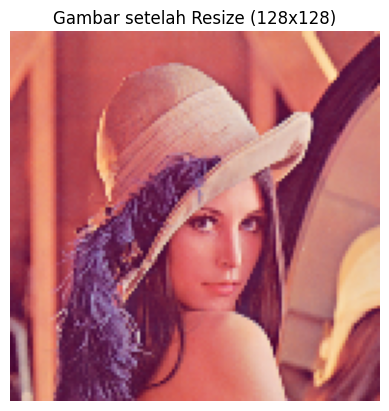

In [27]:
# Resize gambar
img_resized = cv2.resize(img_rgb, (128, 128))

plt.imshow(img_resized)
plt.title("Gambar setelah Resize (128x128)")
plt.axis("off")
plt.show()

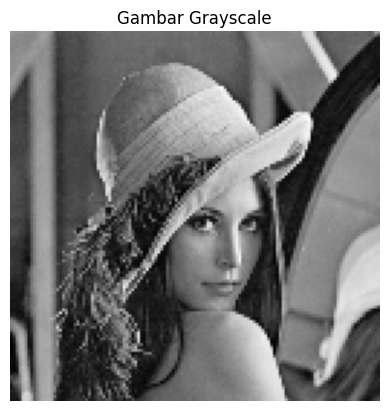

In [28]:
# Konversi ke grayscale
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.title("Gambar Grayscale")
plt.axis("off")
plt.show()

# tugas

In [30]:
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [31]:
#cek tipe dimensi
df.shape

# cek tipe data
df.info()

#jumlah data hilang
df.isnull().sum()

#ringkasan nilai statik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB


,Plant_ID,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
count,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000
mean,35.441780,28.142222,64.873462,598.045440,6.399211,23.141054,82.655999,0.648735
std,20.243433,4.670521,8.988985,115.713047,0.234418,13.077107,8.406938,0.089890
min,1.000000,18.000000,50.000000,400.000000,6.000000,1.000000,64.400000,0.500000
25%,18.000000,23.600000,57.000000,498.000000,6.200000,12.000000,74.480000,0.570000
50%,35.000000,30.200000,65.000000,593.000000,6.400000,23.000000,86.360000,0.650000
75%,53.000000,31.500000,73.000000,699.000000,6.600000,34.000000,88.700000,0.730000
max,70.000000,33.500000,80.000000,800.000000,6.800000,48.000000,92.300000,0.800000


In [37]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# 1. Hapus variabel yang tidak digunakan ('Plant_ID').
df = df.drop(columns=['Plant_ID'], errors='ignore')

# 2. Lakukan proses encoding pada data kategorikal/teks.
le = LabelEncoder()
if 'Date' in df.columns:
    df['Date'] = le.fit_transform(df['Date'])

# 3. Lakukan proses standardisasi pada semua kolom numerik
std = StandardScaler()

# Mengambil semua kolom yang bertipe numerik secara otomatis (lebih aman)
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Menerapkan standardisasi pada kolom-kolom tersebut
df[numeric_cols] = std.fit_transform(df[numeric_cols])

# Verifikasi hasil akhir
df.head()

,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Humidity
0,-0.190349,1.125915,-1.321099,-0.138688,0.003366,-1.693383,-1.321099
1,0.027340,1.147329,-1.321099,-1.270977,-1.276599,-1.616901,-1.321099
2,0.099903,1.125915,-0.653510,0.691082,0.003366,-1.540420,-0.653510
3,0.172465,1.125915,0.347874,-1.538924,0.003366,-1.463938,0.347874
4,0.245028,1.125915,1.015463,0.336701,0.430021,-1.387457,1.015463
